#Assignment 1
1. Read two real numbers x,y from user
2. Compute $z=\sqrt{x^2+y^2}$
3. Print z
BONUS: Find intrinsic function

In [ ]:
PROGRAM Assignment1
  IMPLICIT NONE

  REAL::x,y,z

  PRINT *, 'Input x: '
  READ *, x
  PRINT *, 'Input y: '
  READ *, y
  z=(x**2+y**2)**0.5 !BONUS: intrinsic is SQRT(x**2+y**2)
  PRINT *, 'The value of z is ', z

END PROGRAM

#Assignment 2
1. Read integer n from user
2. Check that n>0, else terminate program
3. Compute nth Lucas number

$$L_n=L_{n-1}+L_{n-2};L_0=2;L_1=1$$
* USE [DO...END DO] and intrinsic STOP

BONUS
* If the user input is not in expected range, print an error message and keep prompting the user.



In [ ]:
PROGRAM Assignment2
  IMPLICIT NONE
  INTEGER :: n, i, L, L0, L1
  L0=2
  L1=1
  PRINT*, 'Enter an integer greater than 0 : '
  READ*, n
  IF (n>0) THEN
    IF (n==1) THEN
        L=1
    ELSE
        DO i=2,n
            L=L1+L0
            L0=L1
            L1=L
            PRINT *,i,L
        END DO
    END IF
	  PRINT*, 'The Lucas number for',n,'is',L
  ELSE
	  PRINT*, 'Error :(((' !BONUS
    STOP
  END IF
END PROGRAM

#Assignment 3
1. Compute the value of $\pi$ using the formula of Madhava of Sangamagrama, founder of the Kerala school of astronomy and mathematics (1340-1425):
$$\pi=4\sum^\infty_{m=0}\biggr(\frac{(-1)^m}{(2m+1)}\biggr)$$
2. Increase the value of $m$ and repeat computation until
$$\arctan(1.0)-0.25 \pi(m)<1.0e-3$$
3. Print the final values of $m$ and $\pi$

BONUS
* Can you get an error <10^-6 using this algorithm and computer real numbers? How?


In [ ]:
REAL FUNCTION pi_madhava(m) RESULT(pi)
  IMPLICIT NONE
  REAL, INTENT(in) :: m
  pi=4.0*((-1.0)**m/(2.0*m+1.0))
END FUNCTION pi_madhava

PROGRAM Assignment3
  IMPLICIT NONE
  REAL :: m, pi, pisum
  REAL, EXTERNAL :: pi_madhava
  m=0
  pisum=0
  PRINT*, "m    pi"
  PRINT*, m, pisum
  DO WHILE (abs(atan(1.0)-0.25*pisum)>=10.0**(-6.0)) !BONUS
    pi=pi_madhava(m)
    pisum=pisum+pi
    PRINT*, m, pisum
    m=m+1
  END DO
END PROGRAM Assignment3

#Assignment 4
1. Create a module to compute:
* Average and standard deviation of any real value array
* Trace and determinant of any 2x2 or 3x3 real value matrix
2. Create program using module.

BONUS
* Use SIZE to manage error if user provides non square or larger matrices

In [ ]:
MODULE Assignment4_mod
  IMPLICIT NONE
  CONTAINS

  !computes average of any real value matrix
    REAL FUNCTION average(matrix) RESULT(res)
    REAL, DIMENSION(:,:), INTENT(IN) :: matrix
    res=SUM(matrix)/REAL(SIZE(matrix))
    END FUNCTION

  !standard deviation of any real value matrix
    REAL FUNCTION standarddeviation(matrix, avg) RESULT(res)
    REAL, DIMENSION(:,:) :: matrix
    REAL, INTENT(IN) :: avg
    REAL :: sum
    INTEGER :: i,j
    sum=0.0
    DO i = 1,UBOUND(matrix,1)
      DO j = 1,UBOUND(matrix,2)
        sum=sum+(matrix(i,j)-avg)**2
      END DO
    END DO
    res=SQRT(sum/SIZE(matrix))
    END FUNCTION

  !trace of 2x2 amd 3x3 real value matrix
    REAL FUNCTION trace(matrix) RESULT(res)
    REAL, DIMENSION(:, :), INTENT(IN) :: matrix
    INTEGER :: i,j
    res=0.0
    IF (UBOUND(matrix,1)==UBOUND(matrix,2)) THEN
      DO i = 1,UBOUND(matrix,1)
        DO j = 1,UBOUND(matrix,2)
          IF (i==j) THEN
            res=res+matrix(i,j)
          END IF
        END DO
      END DO
    ELSE
      PRINT*, "Please input a square matrix!"
    END IF
    END FUNCTION

  !determinant of 2x2 amd 3x3 real value matrix by Rule of Sarrus
    REAL FUNCTION determinant(m) RESULT(res)
    REAL, DIMENSION(:, :), INTENT(IN) :: m
    INTEGER :: i,j
    IF (UBOUND(m,1)==UBOUND(m,2)) THEN !BONUS
      IF (SIZE(m)==4) THEN
        res=m(1,1)*m(2,2)-m(1,2)*m(2,1)
      ELSE IF (SIZE(m)==9) THEN
      	res=m(1,1)*m(2,2)*m(3,3)+m(2,1)*m(3,2)*m(1,3)+&
        m(3,1)*m(1,2)*m(2,3)&-m(3,1)*m(2,2)*m(1,3)-&
        m(1,1)*m(3,2)*m(2,3)-m(2,1)*m(1,2)*m(3,3)
      ELSE
        PRINT*, "Matrix is too big!"
      END IF
    ELSE
      PRINT*, "Please input a square matrix!"
    END IF
    END FUNCTION

END MODULE

In [ ]:
PROGRAM Assignment4
  USE Assignment4_mod
  IMPLICIT NONE
  REAL, DIMENSION (:,:), ALLOCATABLE :: matrix
  REAL :: avg, stdev, trc, det
  INTEGER :: i,j,imax,jmax, r
  PRINT*,"How many rows in the matrix : "
  READ*, imax
  PRINT*,"How many columns in the matrix : "
  READ*, jmax
  ALLOCATE(matrix(imax,jmax))
  DO i = 1,imax
    DO j = 1,jmax
      PRINT*, "Input element (",i,j,") : "
      READ*, r
      matrix(i,j)=r
    END DO
  END DO
  avg=average(matrix)
  PRINT*, "average:", avg
  stdev=standarddeviation(matrix,avg)
  PRINT*, "standard deviation:", stdev
  trc=trace(matrix)
  PRINT*, "trace:", trc
  det=determinant(matrix)
  PRINT*, "determinant:", det

END PROGRAM

#Assignment 5

1. Ask the user the number of rows and columns contained in the file
2. Allocate the space to read in the data from the file
3. Read the data line by line, storing values
4. Compute the column by column average of the values and write the result on a single line in the file result.txt

BONUS
* Modify the program to find the number of rows and columns

SUPER BONUS
* Can you modify the program to skip eventual header lines in the file starting with the character #
  * Assume lines of max 80 characters
  * look into intrinsic REWIND

In [ ]:
PROGRAM Assignment5 !write file
  IMPLICIT NONE
  INTEGER :: rows, columns, u, i, j, rows1, columns1
  REAL(8), DIMENSION (:,:), ALLOCATABLE :: matrix
  REAL(8), DIMENSION (:), ALLOCATABLE :: mean
  PRINT*, "How many rows are in your file?"
  READ*, rows
  PRINT*, "How many columns are in your file?"
  READ*, columns
  ALLOCATE(matrix(columns,rows))
  ALLOCATE(mean(columns))
  OPEN(UNIT=u, FILE="data.txt", STATUS="old", ACTION="read")
  DO i = 1, rows
    READ(u, "(3f8.2)") matrix(1,i), matrix(2,i), matrix(3,i)
  END DO
  PRINT*, matrix
  DO i = 1, columns
    mean(i)=0
  END DO
  DO i = 1, rows
   DO j = 1, columns
     mean(j)=mean(j)+matrix(j,i)
   END DO
  END DO
  PRINT*, "The mean for the first column is:", mean(1)/rows
  PRINT*, "The mean for the second column is:", mean(2)/rows
  PRINT*, "The mean for the second column is:", mean(3)/rows
END PROGRAM

#Comprehension Test
1. Read the elements of an array of real values stored in the file **sample.dat**.
2. Sort the array values in ascending order by using the code in the module **module_sorter.f90**.
3. Compute the mean of the values in the array.
4. Compute the standard deviation of the values in the array.
5. Compute the $98th$ percentile of the distribution.
$$m^{th} percentile =\biggr[\frac{m\times N}{100}\biggr]^{th} element$$
6. Write in an output file **result.dat** the values above computed in the following format:
* #THIS IS COMPUTED FROM THE SAMPLE/DAT
* #MEAN  STD   98PCT
* #aaaaaa.bbbcccccc.dddeeeeee.fff

In [ ]:
module module_sorter
  implicit none
  private

  public :: quicksort

  contains

  recursive subroutine quicksort(a)
    real, dimension(:), intent(inout) :: a
    integer :: p
    if (size(a) == 0) return
    p = partition(a)
    call quicksort(a(:p-1))
    call quicksort(a(p+1:))
  end subroutine quicksort

  integer function partition(a) result(i)
    real, dimension(:), intent(inout) :: a
    integer :: j
    i = 1
    do j = 1, size(a)
        if (a(j) < a(size(a))) then
            call swap(a(i), a(j))
            i = i + 1
        end if
    end do
    call swap(a(i), a(size(a)))
  end function partition

  elemental subroutine swap(a, b)
    real, intent(inout) :: a, b
    real :: temp
    temp = a
    a = b
    b = temp
  end subroutine swap

end module module_sorter

#ifdef TESTME
program testsort
  use module_sorter
  implicit none
  real, dimension(10) :: array = [10.0,9.0,8.0,6.0,7.0,5.0,4.0,3.0,2.0,1.0]
  call quicksort(array)
  print *, array
end program testsort
#endif

In [ ]:
PROGRAM mockexam
  USE module_sorter
  IMPLICIT NONE
  INTEGER :: i, u, v
  REAL :: avg, stdev, prc
  REAL, DIMENSION (1439) :: vector

  u=10
  OPEN(UNIT=u, FILE="sample.dat", STATUS="old", ACTION="read")
  DO i = 1, 1439
    READ(u, "(f10.3)") vector(i)
  END DO
  CLOSE(u)

  avg = average(vector)
  PRINT*, "average:", avg

  stdev = standarddeviation(vector,avg)
  PRINT*, "standard deviation:", stdev

  call sort(vector)
  prc = percentile(vector)
  PRINT*, "percentile:", prc

  v=11
  OPEN(UNIT=v, FILE="result.dat", STATUS="replace", ACTION="write")
  WRITE(v,'(a)') "# THIS IS COMPUTED FROM SAMPLE/DAT"
  WRITE(v,'(a)') "#     MEAN       STD     98PCT"
  WRITE(v, "(3f10.3)") avg, stdev, prc
  CLOSE(v)
END PROGRAM

#Assignment 6

1. Find the root of the function
$$f(x)=x^5+3x^4-2x^2-\ln(x^2)-2$$
in the interval [-2,-1] with a precision $1.0E-7$ by using:
* The Bisection method
* The Regula Falsi method
2. Write on output the last iteration step and the value of the estimated solution
* Use SUBROUTINE

In [ ]:
REAL(8) FUNCTION fxn(x) RESULT(res)
  IMPLICIT NONE
  REAL(8), INTENT(IN) :: x
  res=x**5+3*x**4-2*x**2-log(x**2)-2
END FUNCTION fxn

SUBROUTINE bisect(a1,b1,a,b,c,i)
  REAL(8), INTENT(IN) :: a1,b1
  REAL(8) :: c,e,a,b
  INTEGER :: i
  REAL(8), EXTERNAL :: fxn
  a=a1
  b=b1
  e=1.0E-7
  i=1
  PRINT*,e
  DO WHILE (abs(b-a)>=e)
    c=(a+b)/2
    IF (fxn(b)*fxn(c)<=0) THEN
      a=c
    ELSE
      b=c
    END IF
    i=i+1
  END DO
END SUBROUTINE bisect

SUBROUTINE falsi(a1,b1,a,b,c,j)
  REAL(8), INTENT(IN) :: a1,b1
  REAL(8) :: c,e,a,b
  INTEGER :: j
  REAL(8), EXTERNAL :: fxn
  a=a1
  b=b1
  e=1.0E-7
  j=1
  DO WHILE (abs(b-a)>10.0**(-7.0))
    c=(fxn(b)*a-fxn(a)*b)/(fxn(b)-fxn(a))
    IF (fxn(b)*fxn(c)<=0) THEN
      a=c
    ELSE
      b=c
    END IF
    j=j+1
  END DO
END SUBROUTINE falsi


PROGRAM Assignment6
  IMPLICIT NONE
  REAL(8) :: a1,b1,a,b,c
  INTEGER :: i,j
  REAL(8), EXTERNAL :: fxn
  a1=-2.0
  b1=-1.0
  CALL bisect(a1,b1,a,b,c,i)
  PRINT*, "Bisection algorithm"
  PRINT*, "a=",a,"b=", b, "i=", i
  CALL falsi(a1,b1,a,b,c,j)
  PRINT*, "Falsi algorithm"
  PRINT*, "a=",a,"b=", b, "j=", j
END PROGRAM

#Assignment 7

1. Find the root of the function
$$f(x)=\cos(x)-\ln(x)+1.0$$
in the interval [1,3] with a precision of $1.0E-7$ using:
* The Bisection method
* The Regula Falsi method
* The Newton method starting from $x_0=1.0$
* The secant method

BONUS
* Find all 3 roots!

In [ ]:
REAL(8) FUNCTION fxn(x) RESULT(res)
  IMPLICIT NONE
  REAL(8), INTENT(IN) :: x
  res=cos(x)-log(x)+1.0
END FUNCTION fxn

REAL(8) FUNCTION dfxn(x) RESULT(res)
  IMPLICIT NONE
  REAL(8), INTENT(IN) :: x
  res=-sin(x)-log(x)
END FUNCTION dfxn

SUBROUTINE bisect(a1,b1,a,b,c,i)
  REAL(8), INTENT(IN) :: a1, b1
  REAL(8) :: a,b,c,e
  INTEGER :: i
  REAL(8), EXTERNAL :: fxn
  a=a1
  b=a2
  e=1.0E-7
  i=1
  DO WHILE (abs(b-a)>=e)
    c=(a+b)/2
    IF (fxn(b)*fxn(c)<=0) THEN
      a=c
    ELSE
      b=c
    END IF
    i=i+1
  END DO
END SUBROUTINE bisect

SUBROUTINE falsi(a1,b1,a,b,c,j)
  REAL(8), INTENT(IN) :: a1, b1
  REAL(8) :: a,b,c
  INTEGER :: j
  REAL(8), EXTERNAL :: fxn
  a=a1
  b=b1
  e=1.0E-7
  j=1
  DO WHILE (abs(b-a)>10.0**(-7.0))
    c=(fxn(b)*a-fxn(a)*b)/(fxn(b)-fxn(a))
    IF (fxn(b)*fxn(c)<=0) THEN
      a=c
    ELSE
      b=c
    END IF
    j=j+1
  END DO
END SUBROUTINE falsi

SUBROUTINE newton(x,x0,x1,k)
  REAL(8), INTENT(IN) :: x
  REAL(8) :: x0,x1
  INTEGER :: k
  REAL(8), EXTERNAL :: fxn, dfxn
  x0=x
  x1=x0-fxn(x0)/dfxn(x0)
  k=1
  DO WHILE (abs(x1-x0)>10.0**(-7.0))
    x0=x1
    x1=x0-fxn(x0)/dfxn(x0)
    k=k+1
  END DO
END SUBROUTINE

SUBROUTINE secant(x00,x11,x0,x1,x2,l)
  REAL(8), INTENT(IN) :: x00, x11
  REAL(8) :: x0,x1,x2
  INTEGER :: l
  REAL(8), EXTERNAL :: fxn, dfxn
  x0=x00
  x1=x11
  x2=x1-fxn(x1)*(x1-x0)/(fxn(x1)-fxn(x0))
  l=1
  DO WHILE (abs(x1-x2)>10.0**(-7.0))
    x0=x1
    x1=x2
    x2=x1-fxn(x1)*(x1-x0)/(fxn(x1)-fxn(x0))
    l=l+1
  END DO
END SUBROUTINE

PROGRAM Assignment7
  IMPLICIT NONE
  REAL(8) :: a1, b1, a,b,c,x0,x1,x2
  a1=1.0
  b1=3.0
  x=1.0
  x00=1.0
  x11=3.0
  INTEGER :: i,j,k,l
  REAL(8), EXTERNAL :: fxn
  CALL bisect(a1,b1,a,b,c,i)
  PRINT*, "Bisection algorithm"
  PRINT*, "a=",a,"b=", b, "i=", i
  CALL falsi(a1,b1,a,b,c,j)
  PRINT*, "Falsi algorithm"
  PRINT*, "a=",a,"b=", b, "j=", j
  CALL newton(x,x0,x1,k)
  PRINT*, "Newton algorithm"
  PRINT*, "x0=",a,"x1=", b, "k=", k
  CALL secant(x00,x11,x0,x1,x2,l)
  PRINT*, "Secant algorithm"
  PRINT*, "x1=",a,"x2=", b, "l=", l
END PROGRAM

#Assignment 8

1. Read from the file **input_data.dat** the column values of time and measurement.
2. Compute the linear interpolated values at times using constant value extrapolation.
$$[1,12,23,34,45,56,67,78,89,100]$$
3. Write the results in the file **output_data.dat** with the same format of the input
4. Repeat the aboce for the file **input_data1.dat**, using linear extrapolation out of the sampled times.

BONUS
* Plot the data.


In [ ]:
PROGRAM Assignment8
  IMPLICIT NONE
  INTEGER :: i, k, u, v, w, x
  REAL, DIMENSION (2,100) :: matrix1, matrix2
  REAL, DIMENSION(2,10) :: values
  values=RESHAPE((/1,0,12,0,23,0,34,0,45,0,56,0,67,0,78,0,89,0,100,0/),shape(values))

  !constant extrapolation
  u=10
  OPEN(UNIT=u, FILE="input_data.dat", STATUS="old", ACTION="read")
  DO i = 1, 100
    READ(u, "(2f7.2)") matrix1(1,i), matrix1(2,i) !save input_data into matrix1
  END DO
  CLOSE(u)

  DO i=1,10 !for every value
    k=1
    DO WHILE (matrix1(1,k)<=values(1,i))
      k=k+1 !count up until x1
    END DO
    IF (k==1 .AND. matrix1(1,1)>values(1,i)) THEN
      values(2,i)=matrix1(2,1)
    ELSE IF (matrix1(1,100)<values(1,i)) THEN
      values(2,i)=matrix1(2,100)
    ELSE
      values(2,i)=matrix1(2,k)+(matrix1(2,k+1)-matrix1(2,k))/(matrix1(1,k+1)-matrix1(1,k))*(values(1,i)-matrix1(1,k))
    END IF
  END DO

  v=11
  OPEN(UNIT=v, FILE="output_data.dat", STATUS="replace", ACTION="write")
  write(v,"(2f7.2)") values !write matrix2 to output_data
  CLOSE(v)

  !linear extrapolation
  w=12
  OPEN(UNIT=w, FILE="input_data1.dat", STATUS="old", ACTION="read")
  DO i = 1, 100
    READ(w, *) matrix2(1,i), matrix2(2,i) !save input_data into matrix1
  END DO
  CLOSE(w)

  DO i=1,10 !for every value
    k=1
    DO WHILE (matrix2(1,k)<=values(1,i))
      k=k+1 !count up until x1
    END DO
    IF (k==1 .AND. matrix2(1,1)>values(1,i)) THEN
      values(2,i)=matrix2(2,k)-(matrix2(2,k+2)-matrix2(2,k))/(matrix2(1,k+2)-matrix2(1,k))*(-values(1,i)+matrix2(1,k))
    ELSE IF (matrix2(1,100)<values(1,i)) THEN
      values(2,i)=matrix2(2,k)+(matrix2(2,k)-matrix2(2,k-2))/(matrix2(1,k)-matrix2(1,k-2))*(values(1,i)-matrix2(1,k))
    ELSE
      values(2,i)=matrix2(2,k)+(matrix2(2,k+1)-matrix2(2,k))/(matrix2(1,k+1)-matrix2(1,k))*(values(1,i)-matrix2(1,k))
    END IF
  END DO

  x=13
  OPEN(UNIT=x, FILE="output_data1.dat", STATUS="replace", ACTION="write")
  WRITE(x,"(2f7.2)") values !write matrix2 to output_data1
  CLOSE(x)

END PROGRAM

#Assignment 9
1. Read from the file **matrix.dat** the coefficients and the known terms of the linear system $Ax=b$, separated by an empty line.
2. Find the solution of the linear system using Cramer rule.

BONUS
* In the module **lup_solver.f90**, a naive implementation of LUP solver is provided. Use it to solve the same system.


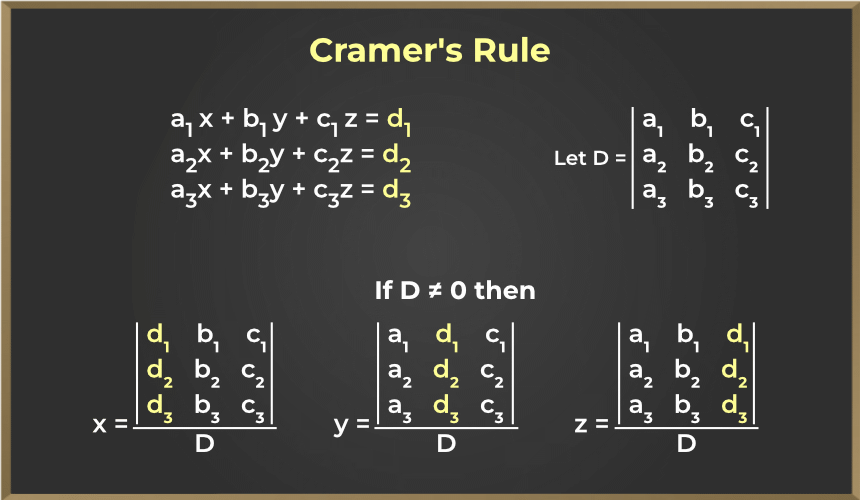


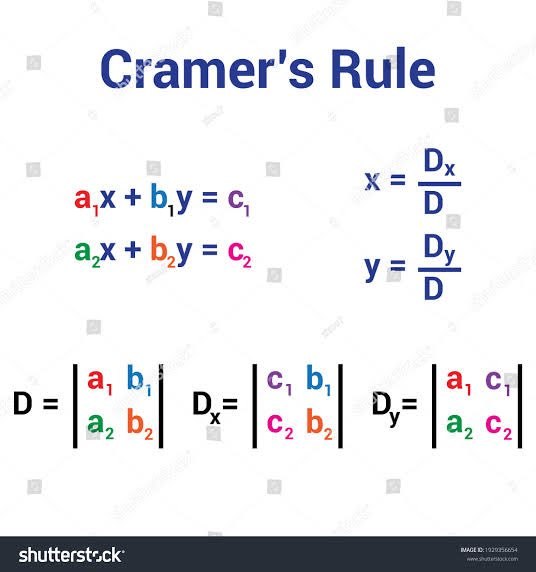

In [ ]:
MODULE Ass09_mod
  IMPLICIT NONE
  CONTAINS

  !determinant 3x3 real value matrix
  REAL FUNCTION determinant(m) RESULT(res)
    REAL, DIMENSION(3,3) :: m
    INTEGER :: i,j
    res=m(1,1)*m(2,2)*m(3,3)+m(2,1)*m(3,2)*m(1,3)+m(3,1)*m(1,2)*m(2,3)-m(3,1)*m(2,2)*m(1,3)-m(1,1)*m(3,2)*m(2,3)-m(2,1)*m(1,2)*m(3,3)
  END FUNCTION

END MODULE

In [ ]:
PROGRAM Assignment9
  USE Ass09_mod
  IMPLICIT NONE
  INTEGER :: u, i
  REAL :: detD, detx, dety, detz, x, y, z
  REAL, DIMENSION (3,3) :: Dm, xm, ym, zm
  REAL, DIMENSION (1,3) :: bm

  !reading matrix.dat into D matrix and b matrix
  u=10
  OPEN(UNIT=u, FILE="matrix.dat", STATUS="old", ACTION="read")
  DO i = 1, 3
    READ(u, *) Dm(1,i), Dm(2,i), Dm(3,i)
  END DO
  READ(u,*)
  READ(u,*) bm(1,1), bm(1,2), bm(1,3)
  CLOSE(U)

  !reading D matrix and b matrix into x, y, and z matrices
  DO i =1,3 !x
    xm(1,i)=bm(1,i)
    xm(2,i)=Dm(2,i)
    xm(3,i)=Dm(3,i)
  END DO
  DO i =1,3 !y
    ym(1,i)=Dm(1,i)
    ym(2,i)=bm(1,i)
    ym(3,i)=Dm(3,i)
  END DO
  DO i =1,3 !z
    zm(1,i)=Dm(1,i)
    zm(2,i)=Dm(2,i)
    zm(3,i)=bm(1,i)
  END DO

  !computing determinants of matrices using the Rule of Sarrus
  detD=determinant(Dm)
  detx=determinant(xm)
  dety=determinant(ym)
  detz=determinant(zm)
  x=detx/detD
  y=dety/detD
  z=detz/detD

  !print results
  PRINT*, "x=",x, "y=",y, "z=",z
END PROGRAM

#Assignment 10: estimate Hubble's constant
$$v_r=H_0d$$
* $d$ - distance to a galaxy
* $v_r$ - velocity to recession
* $H_0$ - Hubble's constant
1. In the text file *hubble_data.txt*, there is a list of speeds (in $km/s$) and distances ($megaparsec;1parsec\approx3.26ly$).
2. Perform a linear fit to estimate Hubble constant.
* Read speeds and distances in two separate arrays.
* Perform fit with linear model:
$$v_r(d)=\beta_1+\beta_2d$$.
* Print estimates for $\beta_1$, $\beta_2$, their standard errors, and the coefficient of determination $R^2$ in a text file *fit.txt*.

BONUS
Perform fit without interceptm, i.e. with the linear model
$$v_r(d)=\beta d$$

In [ ]:
PROGRAM Assignment10
  IMPLICIT NONE
  INTEGER :: u, i, v
  REAL(8) :: beta1, beta2, detD, detDx, detDy, meanv, meand, &
  sres, stot, r2, sigma, SEb1, SEb2, ddiff!beta1 is x; beta2 is y
  REAL, DIMENSION (15) :: distance, speed, vestimate
  REAL, DIMENSION (2,2) :: D, Dx, Dy

  !reading hubble_data.txt to 2 matrices
  u=10
  OPEN(UNIT=u, FILE="hubble_data.txt", STATUS="old", ACTION="read")
  READ(u, *) !idc abt the first line
  DO i=1,15
    READ(u, *) speed(i), distance(i)
  END DO
  CLOSE(u)

  !a1=N=15
  D(1,1)=15 !a1
  Dy(1,1)=15 !a1

  !b1=a2=sum(x) or sum of all distances
  D(2,1)= SUM(distance) !b1
  Dx(2,1)= SUM(distance) !b1
  D(1,2)= SUM(distance) !a2
  Dy(1,2)= SUM(distance) !a2

  !c1=sum(y) or sum of all velocities
  Dx(1,1)=SUM(speed) !c1
  Dy(2,1)=SUM(speed) !c1

  !initializing b2 and c2
  D(2,2)=0 !b2
  Dx(2,2)=0 !b2
  Dx(1,2)=0 !c2
  Dy(2,2)=0 !c2

  DO i=1,15
    !b2=sum(x^2) or sum of square distances
    D(2,2)=D(2,2)+distance(i)**2
    Dx(2,2)=Dx(2,2)+distance(i)**2
    !c2=sum(xy) or sum of product of distance and velocity
    Dx(1,2)=Dx(1,2)+distance(i)*speed(i)
    Dy(2,2)=Dy(2,2)+distance(i)*speed(i)
  END DO

  !computing determinants
  detD=D(1,1)*D(2,2)-D(1,2)*D(2,1)
  detDx=Dx(1,1)*Dx(2,2)-Dx(1,2)*Dx(2,1)
  detDy=Dy(1,1)*Dy(2,2)-Dy(1,2)*Dy(2,1)

  !computing beta1 and beta2
  beta1=detDx/detD
  beta2=detDy/detD

  PRINT*, "beta1=", beta1, "beta2=", beta2

  !initializing sres, stot, and mean velocity for r^2
  sres=0
  stot=0
  meanv=SUM(speed)/SIZE(speed)
  !initializing sigma, ddiff, and mean distance for standard error
  sigma=0
  ddiff=0
  meand=SUM(distance)/SIZE(distance)
  DO i=1,15
    vestimate(i)=beta1+beta2*distance(i) !r^2 computation
    sres=sres+(speed(i)-vestimate(i))**2 !r^2 computation
    stot=stot+(speed(i)-meanv)**2 !r^2 computation

    sigma=sigma+(speed(i)-vestimate(i))**2/(13) !sigma^2 for SE
    ddiff=ddiff+(distance(i)-meand)**2
  END DO
  sigma=sigma**0.5 !sigma
  SEb1=sigma*(1/15+meand**2/ddiff)**0.5
  SEb2=sigma*(ddiff)**(-0.5)
  r2=1-sres/stot !r^2 computatiom
  PRINT*, "SEb1=", SEb1, "SEb2=", SEb2
  PRINT*, "R^2=", r2

  v=11
  OPEN(UNIT=v, FILE="fit.txt", STATUS="replace", ACTION="write")
  write(v,*) "beta1=", beta1, "beta2=", beta2
  write(v,*) "SEb1=", SEb1, "SEb2=", SEb2
  write(v,*) "R^2=", r2
  CLOSE(v)

END PROGRAM

#Assignment

In [ ]:
PROGRAM Assignment11
  USE Ass11mod
  IMPLICIT NONE
  REAL(8), DIMENSION(:), ALLOCATABLE :: wavelength, density, residuals
  REAL(8), DIMENSION(:,:), ALLOCATABLE :: jacobian, jtjinvjt
  REAL(8), DIMENSION(2,2) :: inversejtj
  REAL(8), DIMENSION(2):: deltab
  REAL(8) :: beta1, beta2, y, alpha, e, a, b, c, d, coeff
  INTEGER :: i, u, err, k

  u=10
  OPEN(UNIT=u, FILE="sun_data.txt", STATUS="old", ACTION="read")

  !counting how many data lines to allocate to matrices
  READ(u, *) !idc abt the 1st line
  READ(u, *) !idc abt the 2nd line
  i=1
  DO
    READ(u, *, IOSTAT=err)
    IF (err /= 0) EXIT
    i=i+1
  END DO
  i=i-1

  !allocate to matrices
  ALLOCATE(wavelength(i))
  ALLOCATE(density(i))
  ALLOCATE(residuals(i))
  ALLOCATE(jacobian(2,i))
  ALLOCATE(jtjinvjt(i,2))

  !read file to matrices
  REWIND(u)
  READ(u, *) !idc abt the 1st line
  READ(u, *) !idc abt the 2nd line
  i=1
  DO
    READ(u, *, IOSTAT=err) wavelength(i), density(i)
    IF (err /= 0) EXIT
    i=i+1
  END DO
  CLOSE(u)

  !initial values
  beta1=1.0
  beta2=1.0
  alpha=0.1
  e=10**(-6.0)

  DO
    DO k=1,i
      !constructing vector r of residuals
      residuals(k)=density(k)-fxn(wavelength(k),beta1,beta2)

      !constructing the jacobian matrix
      jacobian(1,k)=db1fxn(wavelength(k),beta2)
      jacobian(2,k)=db2fxn(wavelength(k),beta1,beta2)
    END DO

    !Finding the descent direction delta B
    inversejtj=MATMUL(jacobian,TRANSPOSE(jacobian))
    a=inversejtj(1,1)
    b=inversejtj(2,1)
    c=inversejtj(1,2)
    d=inversejtj(2,2)
    coeff=1/(a*d-b*c)
    inversejtj(1,1)=coeff*d
    inversejtj(2,1)=coeff*(-b)
    inversejtj(1,2)=coeff*(-c)
    inversejtj(2,2)=coeff*a
    deltab=MATMUL(residuals,MATMUL(TRANSPOSE(jacobian),inversejtj))
    IF ((deltab(1))**2+(deltab(2))**2<=e) EXIT
    PRINT*, k, beta1, beta2
    beta1=beta1+alpha*(deltab(1))
    beta2=beta2+alpha*(deltab(2))
    END DO

END PROGRAM

In [ ]:
PROGRAM Assignment11
  USE Ass11mod
  IMPLICIT NONE
  REAL(8), DIMENSION(:), ALLOCATABLE :: wavelength, density, residuals
  REAL(8), DIMENSION(:,:), ALLOCATABLE :: jacobian
  REAL(8), DIMENSION(2,2) :: D, Dx, Dy, inversejtj
  REAL(8), DIMENSION(1,2):: deltab
  REAL(8), DIMENSION(2) :: jtr, varb
  REAL(8) :: beta1, beta2, y, alpha, e, detD, detDx, detDy, sigma, var, a1, &
  b1, c1, d1, coeff
  INTEGER :: i, u, err, k, j, v

  u=10
  OPEN(UNIT=u, FILE="sun_data.txt", STATUS="old", ACTION="read")

  !counting how many data lines to allocate to matrices
  READ(u, *) !idc abt the 1st line
  READ(u, *) !idc abt the 2nd line
  i=1
  DO
    READ(u, *, IOSTAT=err)
    IF (err /= 0) EXIT
    i=i+1
  END DO
  i=i-1

  !allocate to matrices
  ALLOCATE(wavelength(i))
  ALLOCATE(density(i))
  ALLOCATE(residuals(i))
  ALLOCATE(jacobian(2,i))

  !read file to matrices
  REWIND(u)
  READ(u, *) !idc abt the 1st line
  READ(u, *) !idc abt the 2nd line
  i=1
  DO
    READ(u, *, IOSTAT=err) wavelength(i), density(i)
    IF (err /= 0) EXIT
    i=i+1
  END DO
  CLOSE(u)

  !initial values
  beta1=1.0
  beta2=1.0
  alpha=0.1
  e=10**(-6.0)
  j=1

  DO
    DO k=1,i
      !constructing vector r of residuals
      residuals(k)=density(k)-fxn(wavelength(k),beta1,beta2)

      !constructing the jacobian matrix
      jacobian(1,k)=db1fxn(wavelength(k),beta2)
      jacobian(2,k)=db2fxn(wavelength(k),beta1,beta2)
    END DO

    !Finding the descent direction delta B
    D=MATMUL(jacobian,TRANSPOSE(jacobian))
    jtr=MATMUL(residuals,TRANSPOSE(jacobian))
    !a1
    Dy(1,1)=D(1,1)
    !b1
    Dx(2,1)=D(2,1)
    !a2
    Dy(1,2)=D(1,2)
    !b2
    Dx(2,2)=D(2,2)
    !c1
    Dx(1,1)=jtr(1)
    Dy(2,1)=jtr(1)
    !c2
    Dy(1,2)=jtr(2)
    Dx(1,2)=jtr(2)

    !computing determinants
    detD=D(1,1)*D(2,2)-D(1,2)*D(2,1)
    detDx=Dx(1,1)*Dx(2,2)-Dx(1,2)*Dx(2,1)
    detDy=Dy(1,1)*Dy(2,2)-Dy(1,2)*Dy(2,1)

    !computing beta1 and beta2
    deltab(1,1)=detDx/detD
    deltab(1,2)=detDy/detD

    IF ((deltab(1,1)**2+deltab(1,2)**2)<=e) EXIT
    PRINT*, j, beta1, beta2
    beta1=beta1+alpha*(deltab(1,1))
    beta2=beta2+alpha*(deltab(1,2))
    j=j+1
    END DO
    deltab(1,1)=beta1
    deltab(1,2)=beta2

    sigma=0
    !variance of the error
    DO k=1,i-1
      sigma=sigma+(residuals(k)**2)/(i-2) !sigma^2 for SE
    END DO
    PRINT*,"sigma^2=",sigma

    inversejtj=MATMUL(jacobian,TRANSPOSE(jacobian))
    a1=inversejtj(1,1)
    b1=inversejtj(2,1)
    c1=inversejtj(1,2)
    d1=inversejtj(2,2)
    coeff=sigma/(a1*d1-b1*c1)
    inversejtj(1,1)=coeff*d1
    inversejtj(2,1)=coeff*(-b1)
    inversejtj(1,2)=coeff*(-c1)
    inversejtj(2,2)=coeff*a1
    inversejtj(1,1)=sqrt(inversejtj(1,1))
    inversejtj(2,1)=sqrt(inversejtj(1,1))
    inversejtj(1,2)=sqrt(inversejtj(1,1))
    inversejtj(2,2)=sqrt(inversejtj(1,1))
    PRINT*,"standard error=",inversejtj
    PRINT*,"T [K]=",14387.77/beta2

    v=11
    OPEN(UNIT=v, FILE="fit.txt", STATUS="replace", ACTION="write")
    write(v,*) "beta1=", beta1, "beta2=", beta2
    write(v,*) "sigma^2=",sigma
    write(v,*) "standard error=",inversejtj
    write(v,*) "T [K]=",14387.77/beta2
    CLOSE(v)
END PROGRAM